# 02 - Exploratory Data Analysis

This notebook explores the Heart Disease dataset to understand:
- Feature distributions
- Categorical feature frequencies
- Relationships between features and the target
- Potential outliers
- Potential correlations
- Patterns that may influence preprocessing and model development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/processed.cleveland.data", header=None)

In [2]:
df.shape

(303, 14)

In [3]:
df.columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
num           int64
dtype: object

In [6]:
df["age"].describe()

count    303.000000
mean      54.438944
std        9.038662
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

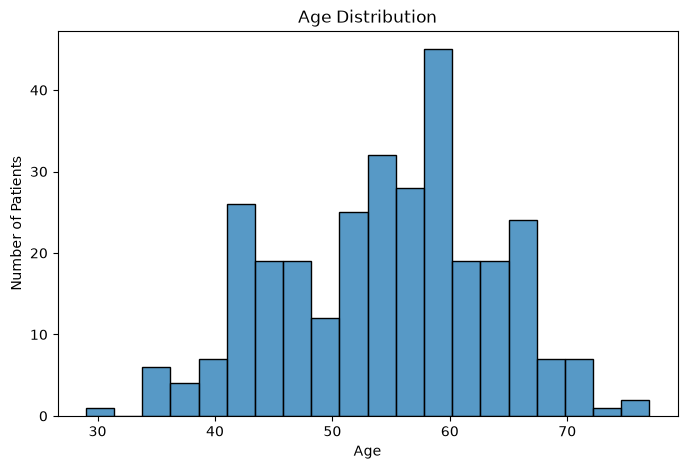

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

### Age Distribution

- Patient ages range from 29 to 77 years.
- The mean age is approximately 54.4 years and the median is 56 years.
- Most observations are concentrated around the 50–60 age range.
- Ages below 40 and above 70 are relatively uncommon.
- The age distribution appears somewhat skewed rather than perfectly symmetric.

In [8]:
df["sex"].value_counts()

sex
1.0    206
0.0     97
Name: count, dtype: int64

In [9]:
df["sex"].value_counts(normalize=True)

sex
1.0    0.679868
0.0    0.320132
Name: proportion, dtype: float64

### Sex Distribution

- The dataset contains 206 male patients and 97 female patients.
- Approximately 68.0% of the observations are male and 32.0% are female.
- The dataset therefore has a noticeably higher proportion of male patients.

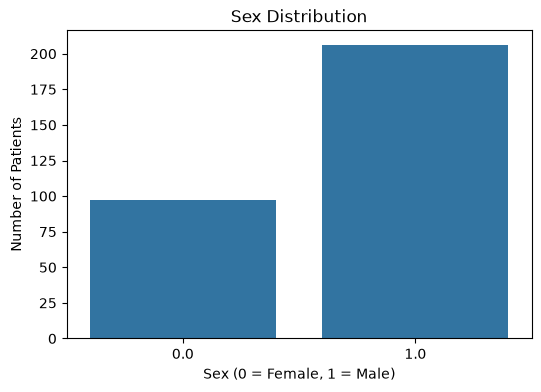

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex")
plt.title("Sex Distribution")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Number of Patients")
plt.show()

In [11]:
df["cp"].value_counts().sort_index()

cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

In [12]:
df["cp"].value_counts(normalize=True).sort_index()

cp
1.0    0.075908
2.0    0.165017
3.0    0.283828
4.0    0.475248
Name: proportion, dtype: float64

### Chest Pain Type Distribution

- The most common chest pain category is `4` (asymptomatic), representing approximately 47.5% of observations.
- Category `3` (non-anginal pain) represents approximately 28.4%.
- Category `2` (atypical angina) represents approximately 16.5%.
- Category `1` (typical angina) is the least common, representing approximately 7.6%.
- The four chest pain categories are therefore not evenly distributed.

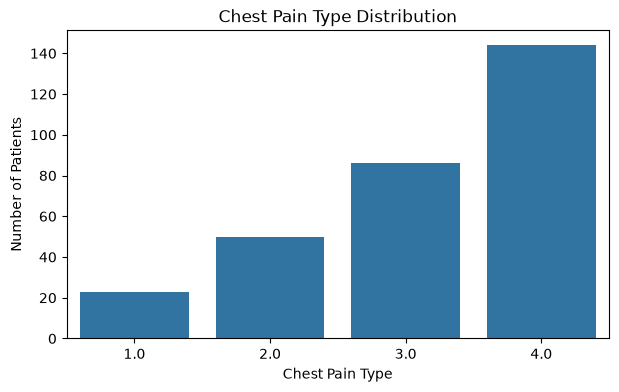

In [13]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="cp")
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.show()

In [14]:
df["trestbps"].describe()

count    303.000000
mean     131.689769
std       17.599748
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

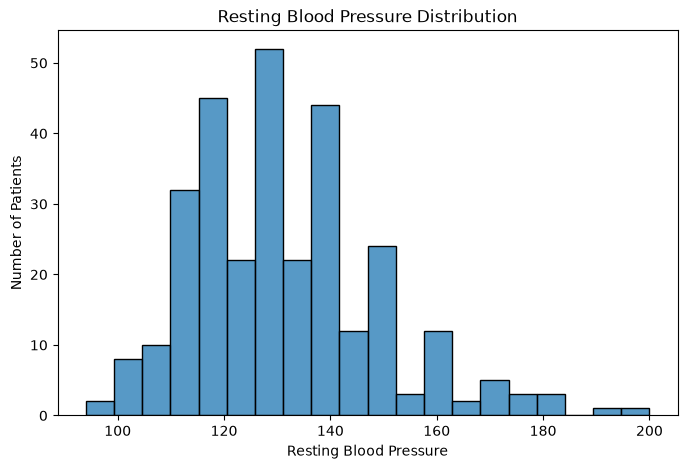

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="trestbps", bins=20)
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Number of Patients")
plt.show()

### Resting Blood Pressure Distribution

- Resting blood pressure values range from 94 to 200.
- The mean resting blood pressure is approximately 131.7, while the median is 130.
- Most observations are concentrated around 120–140.
- The distribution appears somewhat right-skewed, with fewer observations at higher values.
- Values above approximately 150 are relatively uncommon.
- Some high values are present, but they are not automatically treated as outliers or removed at this stage.

In [16]:
df["chol"].describe()

count    303.000000
mean     246.693069
std       51.776918
min      126.000000
25%      211.000000
50%      241.000000
75%      275.000000
max      564.000000
Name: chol, dtype: float64

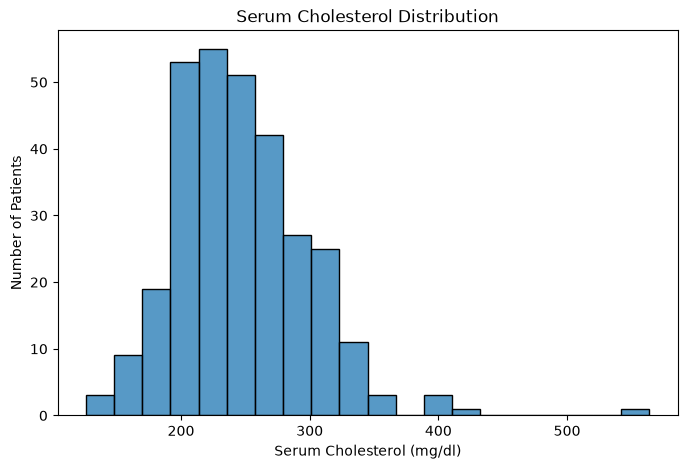

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="chol", bins=20)
plt.title("Serum Cholesterol Distribution")
plt.xlabel("Serum Cholesterol (mg/dl)")
plt.ylabel("Number of Patients")
plt.show()

### Serum Cholesterol Distribution

- Serum cholesterol values range from 126 to 564 mg/dl.
- The mean cholesterol level is approximately 246.7 mg/dl, while the median is 241 mg/dl.
- The middle 50% of observations lie between 211 and 275 mg/dl.
- The distribution is right-skewed, with a long tail toward higher cholesterol values.
- The value around 564 mg/dl is substantially higher than most observations and appears to be an extreme value.
- This value should be retained for now and investigated further rather than automatically removed as an outlier.

In [18]:
df["fbs"].value_counts()

fbs
0.0    258
1.0     45
Name: count, dtype: int64

### Fasting Blood Sugar Distribution

- The dataset contains 258 observations with `fbs = 0` and 45 observations with `fbs = 1`.
- Approximately 85.1% of observations have `fbs = 0`, while 14.9% have `fbs = 1`.
- The feature is therefore noticeably imbalanced toward the `0` category.
- Since `fbs` is a binary categorical feature, its values are treated as categories rather than as continuous numerical measurements.

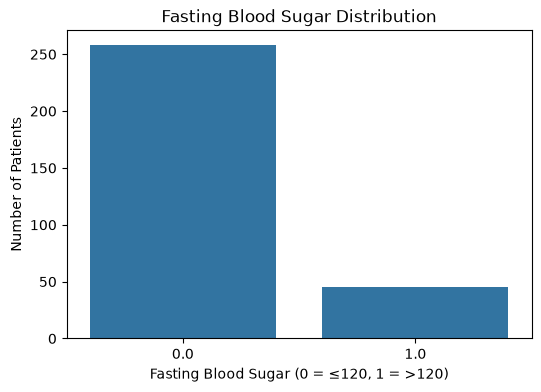

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="fbs")
plt.title("Fasting Blood Sugar Distribution")
plt.xlabel("Fasting Blood Sugar (0 = ≤120, 1 = >120)")
plt.ylabel("Number of Patients")
plt.show()

In [20]:
df["restecg"].value_counts().sort_index()

restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

### Resting ECG Distribution

- The dataset contains 151 observations with `restecg = 0`, 4 observations with `restecg = 1`, and 148 observations with `restecg = 2`.
- Categories `0` and `2` are almost equally represented, accounting for approximately 49.8% and 48.8% of observations respectively.
- Category `1` is very rare, representing approximately 1.3% of observations.
- The feature is categorical, so the numerical codes should be interpreted as categories rather than continuous numerical values.

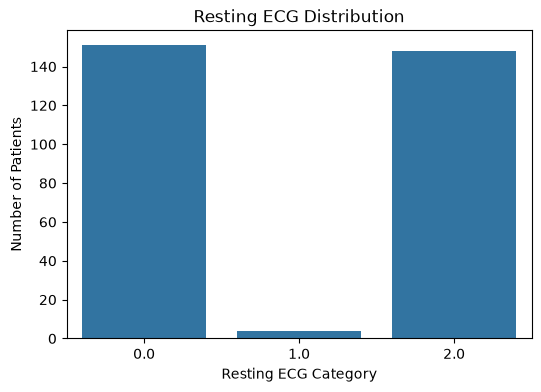

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="restecg")
plt.title("Resting ECG Distribution")
plt.xlabel("Resting ECG Category")
plt.ylabel("Number of Patients")
plt.show()

In [22]:
df["thalach"].describe()

count    303.000000
mean     149.607261
std       22.875003
min       71.000000
25%      133.500000
50%      153.000000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64

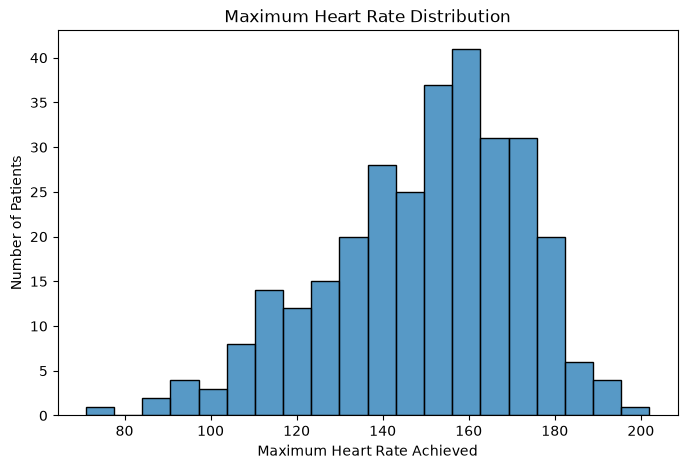

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="thalach", bins=20)
plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate Achieved")
plt.ylabel("Number of Patients")
plt.show()

### Maximum Heart Rate Distribution

- Maximum heart rate values range from 71 to 202.
- The mean maximum heart rate is approximately 149.6, while the median is 153.
- The middle 50% of observations lie between 133.5 and 166.
- The distribution appears somewhat right-skewed, with most observations concentrated around the middle of the range.
- There is an isolated low value below 80 that appears separated from the main concentration of observations.
- This extreme observation is retained for now and will not be removed automatically.

In [24]:
df["exang"].value_counts()

exang
0.0    204
1.0     99
Name: count, dtype: int64

### Exercise-Induced Angina Distribution

- The dataset contains 204 observations with `exang = 0` and 99 observations with `exang = 1`.
- Approximately 67.3% of observations have `exang = 0`, while 32.7% have `exang = 1`.
- The two categories are not evenly distributed, but both contain a substantial number of observations.
- Since `exang` is a binary categorical feature, its values represent categories rather than continuous numerical measurements.

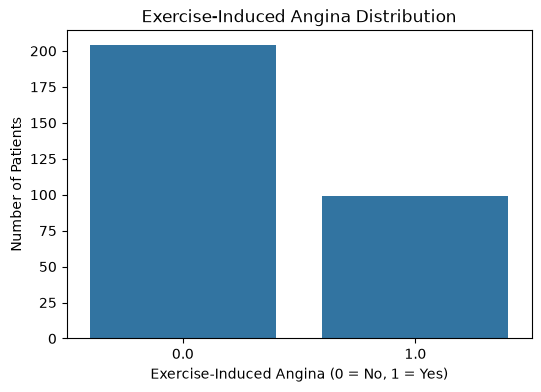

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="exang")
plt.title("Exercise-Induced Angina Distribution")
plt.xlabel("Exercise-Induced Angina (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

In [26]:
df["oldpeak"].describe()

count    303.000000
mean       1.039604
std        1.161075
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64

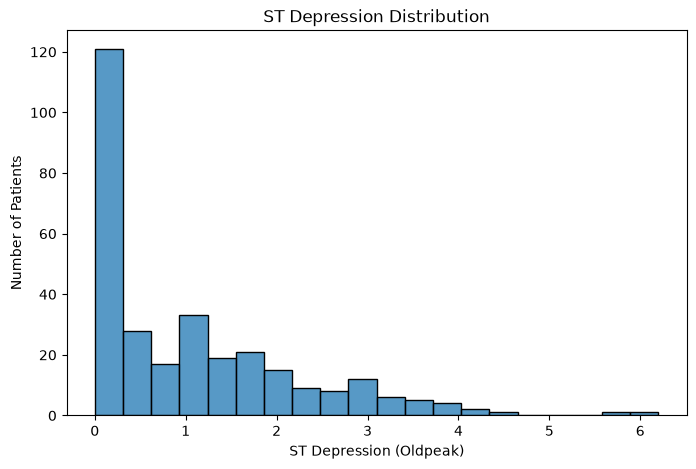

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="oldpeak", bins=20)
plt.title("ST Depression Distribution")
plt.xlabel("ST Depression (Oldpeak)")
plt.ylabel("Number of Patients")
plt.show()

### ST Depression Distribution

- `oldpeak` values range from 0.0 to 6.2.
- The mean is approximately 1.04, while the median is 0.8.
- The distribution is strongly concentrated at 0, with many observations having no measured ST depression.
- The distribution is right-skewed, with fewer observations extending toward higher values.
- The maximum value of 6.2 is considerably higher than the central range and appears to be an extreme observation.
- The extreme values are retained for now and will be investigated further rather than automatically removed.

In [28]:
df["slope"].value_counts().sort_index()

slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

### Slope Distribution

- The dataset contains 142 observations with `slope = 1`, 140 with `slope = 2`, and 21 with `slope = 3`.
- Categories `1` and `2` are almost equally represented, accounting for approximately 46.9% and 46.2% of observations respectively.
- Category `3` is relatively uncommon, representing approximately 6.9% of observations.
- The feature is categorical/ordinal rather than a continuous numerical measurement, so the numerical codes should not be interpreted as continuous values.

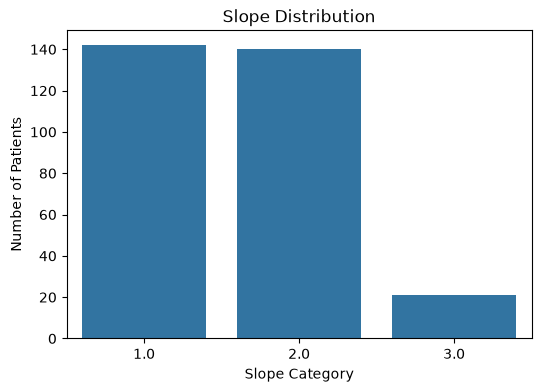

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="slope")
plt.title("Slope Distribution")
plt.xlabel("Slope Category")
plt.ylabel("Number of Patients")
plt.show()

In [30]:
df["ca"].value_counts(dropna=False)

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

### Major Vessels (`ca`) Distribution

- The `ca` feature contains values from 0 to 3, along with 4 missing values represented by `?`.
- `ca = 0` is the most common category, with 176 observations (approximately 58.1%).
- `ca = 1` occurs in 65 observations (approximately 21.5%).
- `ca = 2` occurs in 38 observations (approximately 12.5%).
- `ca = 3` occurs in 20 observations (approximately 6.6%).
- There are 4 missing values, representing approximately 1.3% of the dataset.
- The missing values are retained as `?` in this EDA notebook; their handling will be addressed during preprocessing.

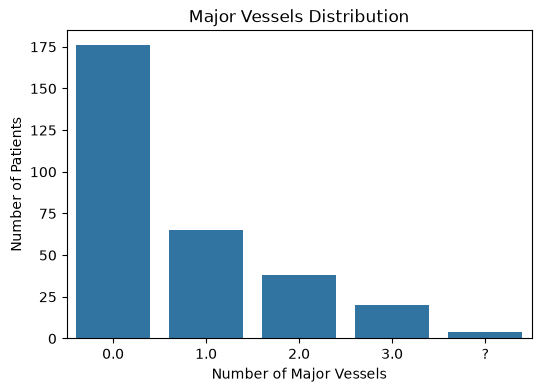

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="ca", order=["0.0", "1.0", "2.0", "3.0", "?"])
plt.title("Major Vessels Distribution")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")
plt.show()

In [32]:
df["thal"].value_counts(dropna=False)

thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64

### Thalassemia Test (`thal`) Distribution

- The `thal` feature contains categories `3`, `6`, and `7`, along with 2 missing values represented by `?`.
- `thal = 3` is the most common category, with 166 observations (approximately 54.8%).
- `thal = 7` occurs in 117 observations (approximately 38.6%).
- `thal = 6` is relatively uncommon, with 18 observations (approximately 5.9%).
- There are 2 missing values, representing approximately 0.7% of the dataset.
- The missing values are retained as `?` in this EDA notebook; their handling will be addressed during preprocessing.
- The numerical codes represent categories rather than continuous numerical measurements.

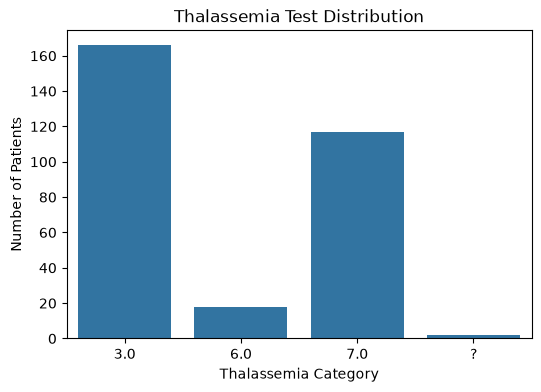

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="thal", order=["3.0", "6.0", "7.0", "?"])
plt.title("Thalassemia Test Distribution")
plt.xlabel("Thalassemia Category")
plt.ylabel("Number of Patients")
plt.show()

In [35]:
df["target"] = (df["num"] > 0).astype(int)
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

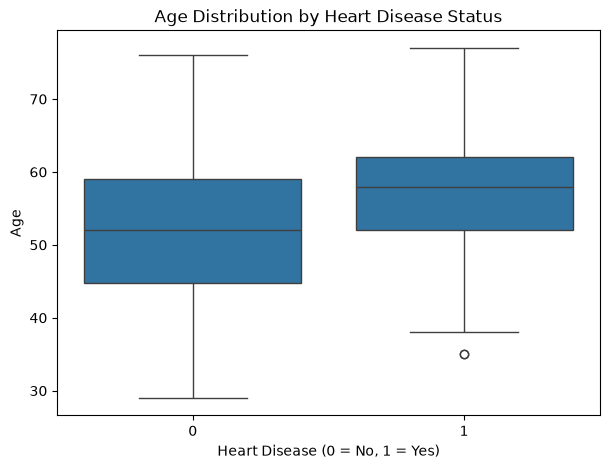

In [36]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="target", y="age")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

### Age vs Heart Disease Status

- The group with heart disease (`target = 1`) has a higher median age than the group without heart disease (`target = 0`).
- The no-disease group (`target = 0`) shows a wider spread of ages.
- An isolated age value appears as an outlier in the heart-disease group.
- The distributions suggest that age may have a relationship with the target, although this visualization alone does not establish causation or predictive importance.

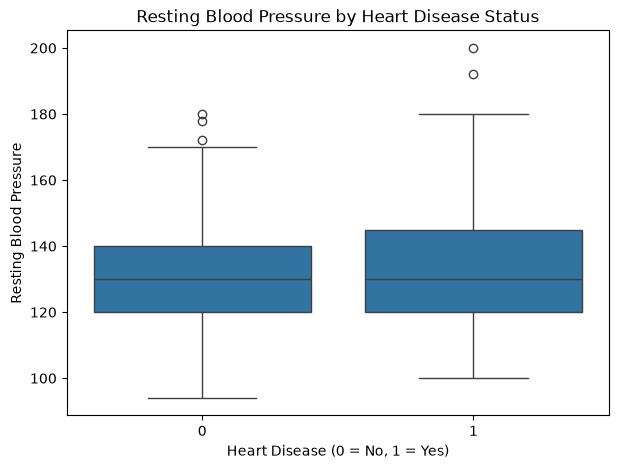

In [37]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="target", y="trestbps")
plt.title("Resting Blood Pressure by Heart Disease Status")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Resting Blood Pressure")
plt.show()

### Resting Blood Pressure vs Heart Disease Status

- The heart-disease group (`target = 1`) has a higher median resting blood pressure than the no-disease group (`target = 0`).
- The heart-disease group also shows a wider spread of resting blood pressure values.
- Both groups contain observations that appear as outliers in the boxplot.
- The distributions suggest that resting blood pressure may have some relationship with the target, although the overlap between the groups should also be considered.

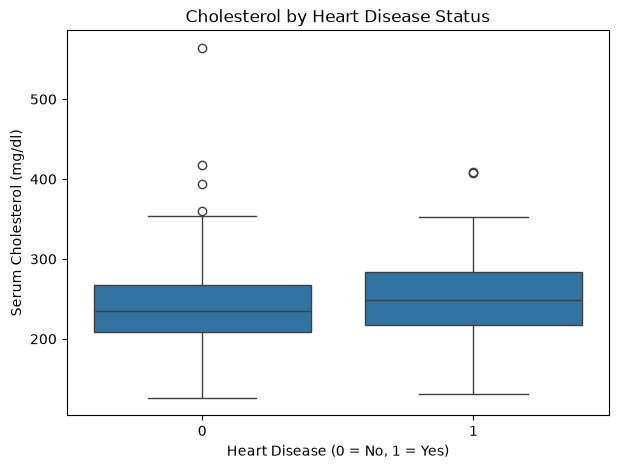

In [38]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="target", y="chol")
plt.title("Cholesterol by Heart Disease Status")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Serum Cholesterol (mg/dl)")
plt.show()

### Cholesterol vs Heart Disease Status

- The heart-disease group (`target = 1`) has a higher median serum cholesterol level than the no-disease group (`target = 0`).
- The heart-disease group also shows a wider spread of cholesterol values.
- Both groups contain observations that appear as outliers in the boxplot.
- There is substantial overlap between the two groups, so cholesterol alone does not clearly separate the target classes.

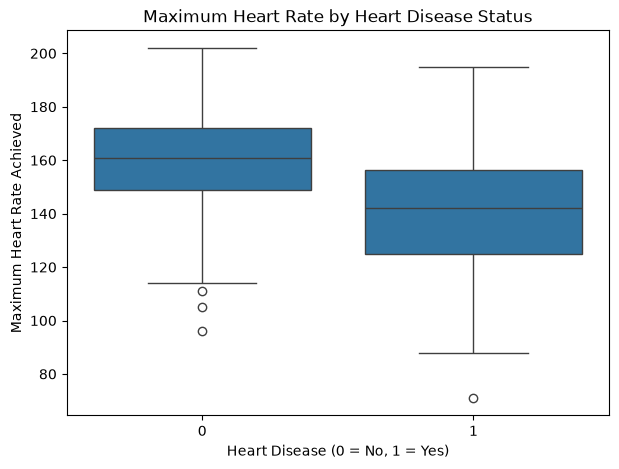

In [39]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="target", y="thalach")
plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate Achieved")
plt.show()

### Maximum Heart Rate vs Heart Disease Status

- The no-disease group (`target = 0`) has a higher median maximum heart rate than the heart-disease group (`target = 1`).
- The heart-disease group shows a wider spread of maximum heart rate values.
- Both groups contain observations that appear as outliers in the boxplot.
- The difference in median values suggests that maximum heart rate may have a relationship with the target.

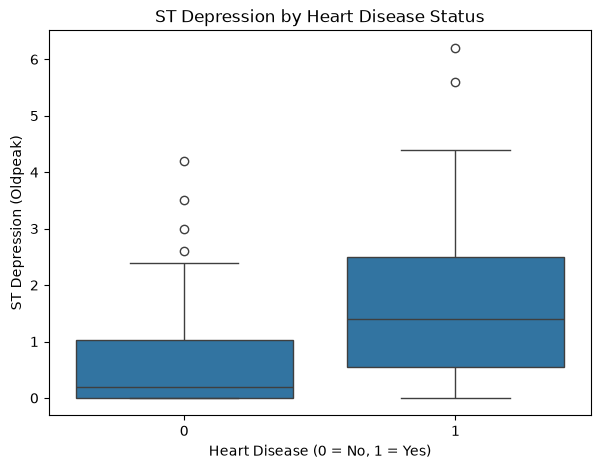

In [40]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="target", y="oldpeak")
plt.title("ST Depression by Heart Disease Status")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("ST Depression (Oldpeak)")
plt.show()

### ST Depression vs Heart Disease Status

- The heart-disease group (`target = 1`) has a higher median ST depression value than the no-disease group (`target = 0`).
- The heart-disease group also shows a wider spread of `oldpeak` values.
- Both groups contain observations that appear as outliers in the boxplot.
- The difference in median values suggests that `oldpeak` may have a relationship with the target.

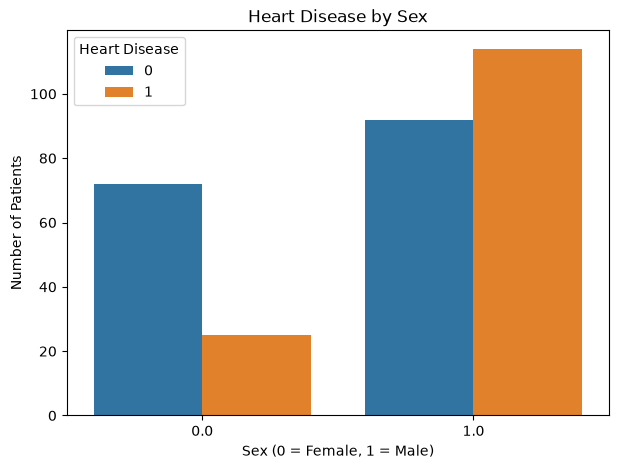

In [41]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sex", hue="target")
plt.title("Heart Disease by Sex")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [42]:
df.groupby("sex")["target"].mean()

sex
0.0    0.257732
1.0    0.553398
Name: target, dtype: float64

### Sex vs Heart Disease Status

- Among patients with `sex = 0` (female), approximately 25.8% have `target = 1`.
- Among patients with `sex = 1` (male), approximately 55.3% have `target = 1`.
- Therefore, the proportion of heart-disease cases is higher in the male group than in the female group in this dataset.
- Comparing proportions rather than raw counts is important because the dataset contains substantially more male than female observations.
- This is an association observed in this dataset and does not by itself establish causation.

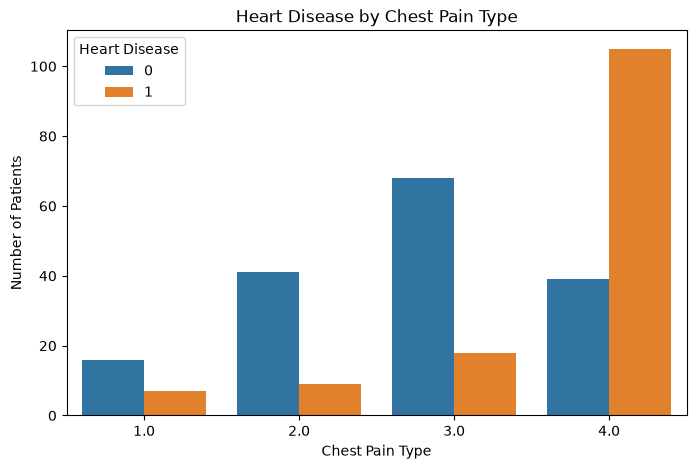

In [43]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="cp", hue="target")
plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [44]:
df.groupby("cp")["target"].mean()

cp
1.0    0.304348
2.0    0.180000
3.0    0.209302
4.0    0.729167
Name: target, dtype: float64

### Chest Pain Type vs Heart Disease Status

- The proportion of heart-disease cases differs substantially across the four chest pain categories.
- For `cp = 1`, approximately 30.4% of observations have `target = 1`.
- For `cp = 2`, approximately 18.0% have `target = 1`.
- For `cp = 3`, approximately 20.9% have `target = 1`.
- For `cp = 4`, approximately 72.9% have `target = 1`.
- Category `4` therefore shows a substantially higher proportion of heart-disease cases than the other chest pain categories in this dataset.
- These are associations observed in this dataset and do not establish causation.

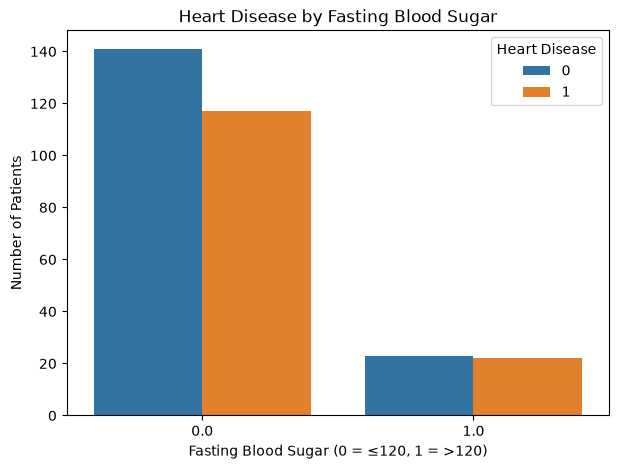

In [45]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="fbs", hue="target")
plt.title("Heart Disease by Fasting Blood Sugar")
plt.xlabel("Fasting Blood Sugar (0 = ≤120, 1 = >120)")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [46]:
df.groupby("fbs")["target"].mean()

fbs
0.0    0.453488
1.0    0.488889
Name: target, dtype: float64

### Fasting Blood Sugar vs Heart Disease Status

- Among observations with `fbs = 0`, approximately 45.3% have `target = 1`.
- Among observations with `fbs = 1`, approximately 48.9% have `target = 1`.
- The proportions are relatively close, so `fbs` does not show a strong difference in heart-disease proportion between the two categories in this dataset.
- This is an association observed in this dataset and does not establish causation.

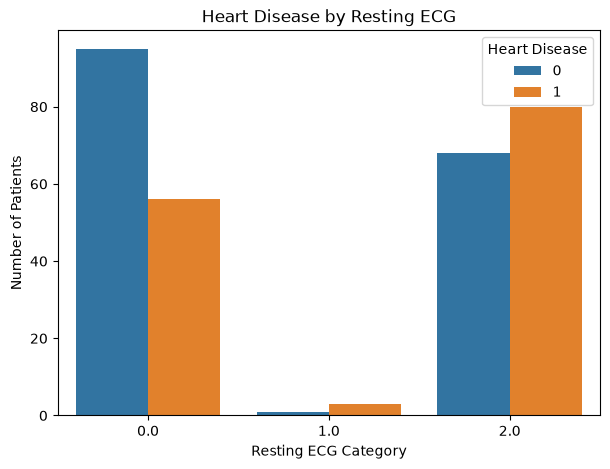

In [47]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="restecg", hue="target")
plt.title("Heart Disease by Resting ECG")
plt.xlabel("Resting ECG Category")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [48]:
df.groupby("restecg")["target"].mean()

restecg
0.0    0.370861
1.0    0.750000
2.0    0.540541
Name: target, dtype: float64

### Resting ECG vs Heart Disease Status

- Among observations with `restecg = 0`, approximately 37.1% have `target = 1`.
- Among observations with `restecg = 1`, 75.0% have `target = 1`.
- Among observations with `restecg = 2`, approximately 54.1% have `target = 1`.
- The proportion of heart-disease cases differs across the three categories.
- However, `restecg = 1` is very rare in this dataset, with only 4 observations, so its 75.0% proportion should be interpreted cautiously.
- The differences represent associations observed in this dataset and do not establish causation.

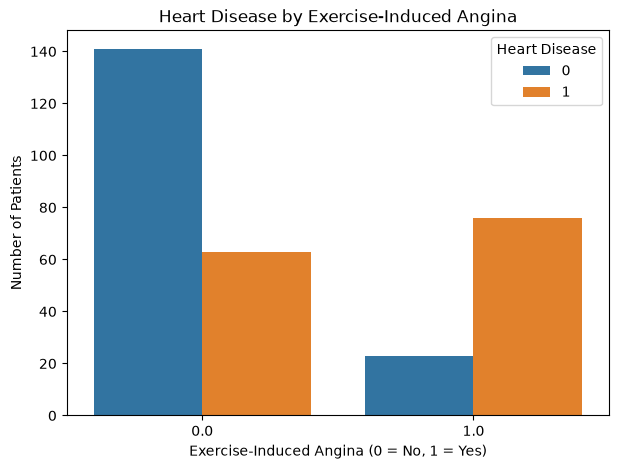

In [49]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="exang", hue="target")
plt.title("Heart Disease by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [50]:
df.groupby("exang")["target"].mean()

exang
0.0    0.308824
1.0    0.767677
Name: target, dtype: float64

### Exercise-Induced Angina vs Heart Disease Status

- Among observations with `exang = 0`, approximately 30.9% have `target = 1`.
- Among observations with `exang = 1`, approximately 76.8% have `target = 1`.
- The proportion of heart-disease cases is substantially higher in the `exang = 1` category.
- This suggests that `exang` may have a strong association with the target in this dataset.
- This is an association observed in the dataset and does not establish causation.

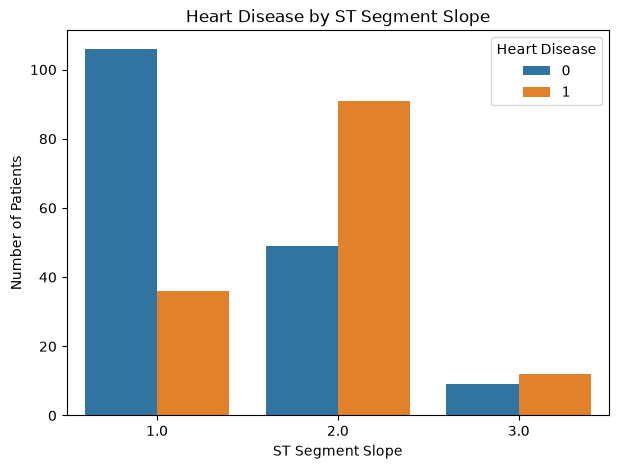

In [51]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="slope", hue="target")
plt.title("Heart Disease by ST Segment Slope")
plt.xlabel("ST Segment Slope")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [52]:
df.groupby("slope")["target"].mean()

slope
1.0    0.253521
2.0    0.650000
3.0    0.571429
Name: target, dtype: float64

### ST Segment Slope vs Heart Disease Status

- The proportion of heart-disease cases differs across the three slope categories.
- `slope = 1` has approximately 25.4% heart-disease cases.
- `slope = 2` has approximately 65.0%.
- `slope = 3` has approximately 57.1%.
- This suggests an association between `slope` and the target in this dataset.
- These observations do not establish causation.

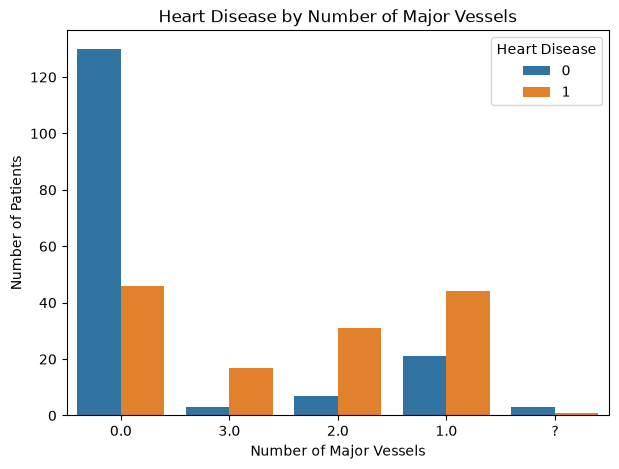

In [53]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="ca", hue="target")
plt.title("Heart Disease by Number of Major Vessels")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [54]:
df.groupby("ca")["target"].mean()

ca
0.0    0.261364
1.0    0.676923
2.0    0.815789
3.0    0.850000
?      0.250000
Name: target, dtype: float64

### Major Vessels (`ca`) vs Heart Disease Status

- The proportion of heart-disease cases increases across the observed `ca` categories.
- `ca = 0` has approximately 26.1% heart-disease cases.
- `ca = 1` has approximately 67.7%.
- `ca = 2` has approximately 81.6%.
- `ca = 3` has approximately 85.0%.
- The missing `?` category contains only 4 observations and should not be interpreted as a meaningful group.
- The observed pattern suggests a strong association between `ca` and the target in this dataset.
- These observations do not establish causation.

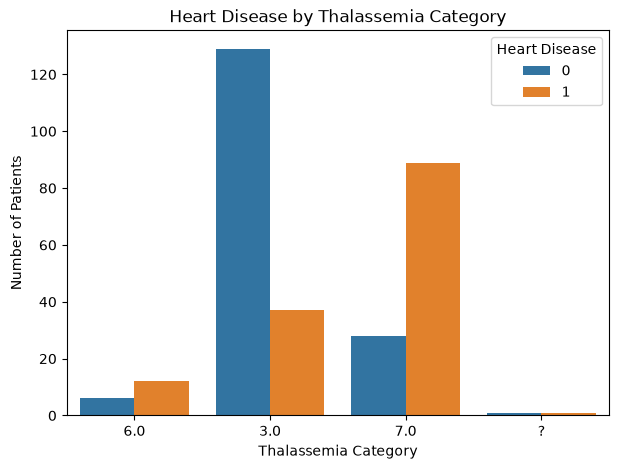

In [55]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="thal", hue="target")
plt.title("Heart Disease by Thalassemia Category")
plt.xlabel("Thalassemia Category")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()

In [56]:
df.groupby("thal")["target"].mean()

thal
3.0    0.222892
6.0    0.666667
7.0    0.760684
?      0.500000
Name: target, dtype: float64

### Thalassemia Test (`thal`) vs Heart Disease Status

- The proportion of heart-disease cases differs substantially across the observed `thal` categories.
- `thal = 3` has approximately 22.3% heart-disease cases.
- `thal = 6` has approximately 66.7%.
- `thal = 7` has approximately 76.1%.
- The missing `?` category contains only 2 observations and should not be interpreted as a meaningful comparison group.
- The observed pattern suggests an association between `thal` and the target in this dataset.
- These observations do not establish causation.

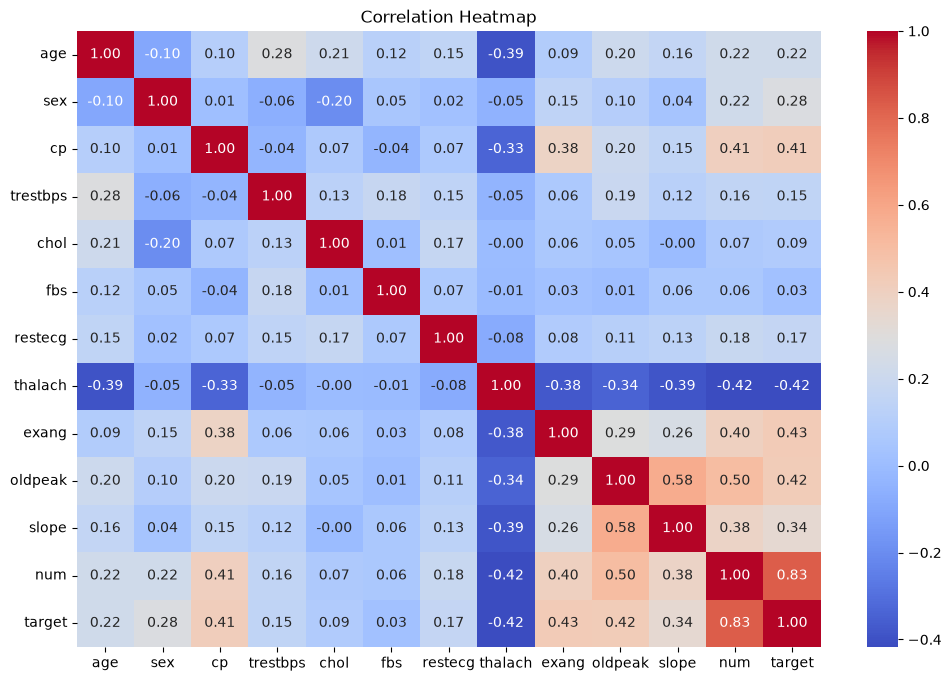

In [57]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- `thalach` shows the strongest negative correlation with the target among the individual features, with a correlation of approximately -0.42.
- `exang`, `oldpeak`, and `cp` show moderate positive correlations with the target, with values of approximately 0.43, 0.42, and 0.41 respectively.
- `slope` shows a weaker positive correlation of approximately 0.34.
- `age` and `sex` have relatively weak positive correlations with the target.
- `fbs` has very little linear correlation with the target, which is consistent with the similar heart-disease proportions observed across its two categories.
- `chol` and `trestbps` also show relatively weak correlations with the target.
- The `num` column has a very high correlation with `target` because `target` was directly derived from `num`. Therefore, `num` must not be used as an input feature during modeling.
- Correlation measures linear relationships and should not be interpreted as proof of causation or as a complete measure of feature importance.